In [1]:
import matplotlib.pyplot as plt

# 이미지 파일 형식을 지원하며, 강력한 이미지 처리와 그래픽 기능을 제공하는 이미지 프로세싱 라이브러리
from PIL import Image

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn.Sequential(
        # 입력 채널 3(RGB) -> 출력 64
        nn.Conv2d(3, 64, kernel_size=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # 채널 64 -> 128
        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # 채널 128 -> 256
        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # 채널 256 -> 512
        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # 채널 512 유지 (심층 특징 추출)
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    # 분류기(classifier) : 추출된 특징을 바탕으로 클래스 결정
    self.classifier = nn.Sequential(
        nn.Linear(512, 512, bias=False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

  # 순전파
  def forward(self, x):
    x = self.features(x)  # 특징 추출부를 통과
    x = x.view(-1, 512)   # 텐서를 1차원으로 펼치기(Flatten)
    x = self.classifier(x)
    return F.log_softmax(x, dim=1) # 로그 소프트맥스로 확률 분포 반환

In [3]:
model = XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [4]:
class LayerActivations:
  features = []

  def __init__(self, model, layer_num):
    # 훅: 모델의 특정 번째(layer_num) 층에 갈고리를 걸어둠
    # 데이터가 해당 층을 통과할 때마다 자동으로 hook_fn이 실행되도록 설정함
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)

  def hook_fn(self, module, input, output):
    # 훅 함수: 해당 층의 계산 결과(output)가 나올 때 호출됨
    # 계산 결과에서 미분 정보 등을 떼어내고(detach) 넘파이 배열로 변환하여 저장
    self.features = output.detach().numpy()

  def remove(self):
    # 훅 제거: 더 이상 관찰이 필요 없을 때 갈고리를 제거하여 메모리 낭비를 방지
    self.hook.remove()

torch.Size([1, 3, 100, 100])


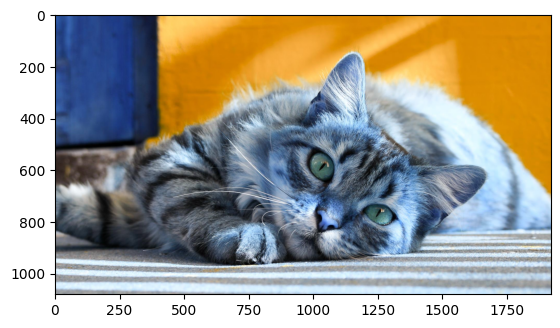

In [5]:
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/feature map/cat.jpg')
plt.imshow(img)

# interpolation=cv2.INTER_LINEAR: 픽셀 사이의 값을 선형 보간법으로 채워 부드럽게 키우거나 줄임
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)

# (H, W, C -> C, H, W)
# unsqueeze(0): 모델은 보통 배치 단위를 기대하므로, 맨 앞에 1차원을 추가하여 (1, C, H, W) 형태로 만듦
img = ToTensor()(img).unsqueeze(0)

# [배치 크기, 채널, 높이, 너비] 순서로 출력됨
print(img.shape)

In [6]:
# 모델의 features 부분 중 0번째 층(첫 번째 Conv2d)에 갈고리를 건다.
# 이제 데이터가 이 층을 통과할 때마다 result 객체 내부의 hook_fn이 자동으로 실행된다.
result = LayerActivations(model.features, 0)

# 준비된 이미지를 모델에 입력한다.
# 이 순간, 이미지 데이터가 각 층을 통과하며 연산이 일어나고, 0번째 층을 지나는 찰나에 위에서 설정한 훅이 데이터를 복사한다.
model(img)

# 훅에 의해 result.features에 저장된 중간 결과값을 꺼내온다.
# activations 변수에는 이제 모델의 첫 번째 필터들이 뽑아낸 특성 맵이 담기게 된다.
activations = result.features

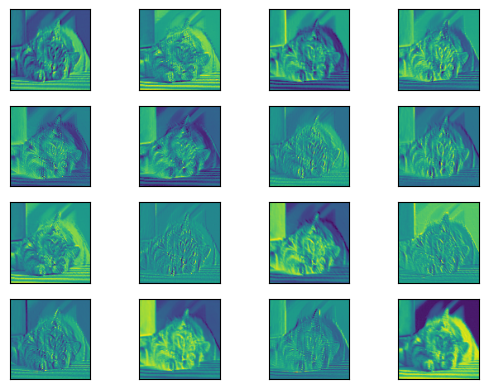

<Figure size 1200x800 with 0 Axes>

In [9]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
# hspace(Height Space): 높이 방향의 간격. 즉 상하 그래프 사이의 여백
# wspace(Weight Space): 너비 방향의 간격. 즉 좌우 그래프 사이의 여백
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [11]:
# VGG 스타일의 모델에서 20번 정도면 꽤 뒷부분에 해당하며,
# 모서리 같은 단순 특징이 아니라, 사물의 형태나 복잡한 질감을 처리하는 단
result = LayerActivations(model.features, 20)

model(img)

# 앞쪽 층(0번)에서 본 결과와 비교하면 훨씬 더 추상적이고 해상도가 낮은 지도가 들어있다.
activations = result.features

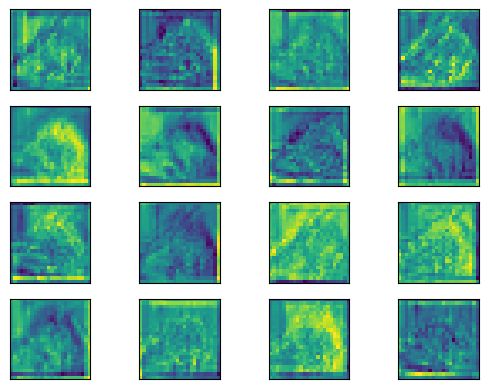

<Figure size 1200x800 with 0 Axes>

In [12]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [13]:
result = LayerActivations(model.features, 40)

model(img)
activations = result.features

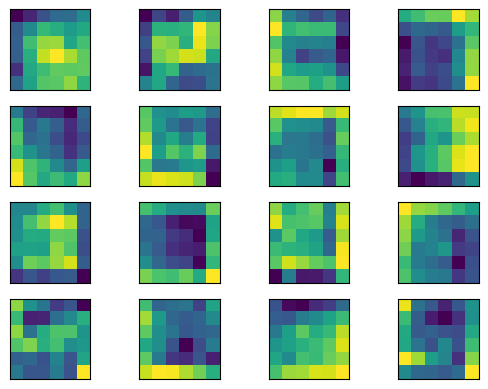

<Figure size 1200x800 with 0 Axes>

In [14]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()